<a href="https://colab.research.google.com/github/rhiosutoyo/Teaching-Deep-Learning-and-Its-Applications/blob/main/02_1_first_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Goal
We are building a simple neural network to predict how many hours a user will spend on a platform next week, based on their movie-watching hours this week.

# Problem Setup
*   Input (x): Average hours watching movies (e.g., this week)
*   Output (y): Predicted hours in the next week



# Project Example
Here’s a simple Python example using Keras (a high-level API in TensorFlow) to build your first neural network for predicting time spent on a platform based on average hours spent watching movies.
1. Training Data. The past data the model learns from
2. Test Data. New data to check how well the model works
3. Model. A basic neural network (just 1 neuron!)
4. Compile. Tell the model how to learn (SGD) and measure error (MSE)
5. Training. Let the model learn the pattern by adjusting itself
6. Prediction. Ask the model to guess outcomes on new data
7. Visualization. See how the model performed over time and on test data


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training the model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

=== Predictions vs Actual (Test Data) ===
Input: 1.5 -> Prediction: 2.46, Actual: 2.2
Input: 2.5 -> Prediction: 3.79, Actual: 3.5
Input: 3.5 -> Prediction: 5.12, Actual: 5.0
Input: 5.5 -> Prediction: 7.78, Actual: 7.9
Input: 6.5 -> Prediction: 9.12, Actual: 9.2
Input: 8.0 -> Prediction: 11.11, Actual: 10.5


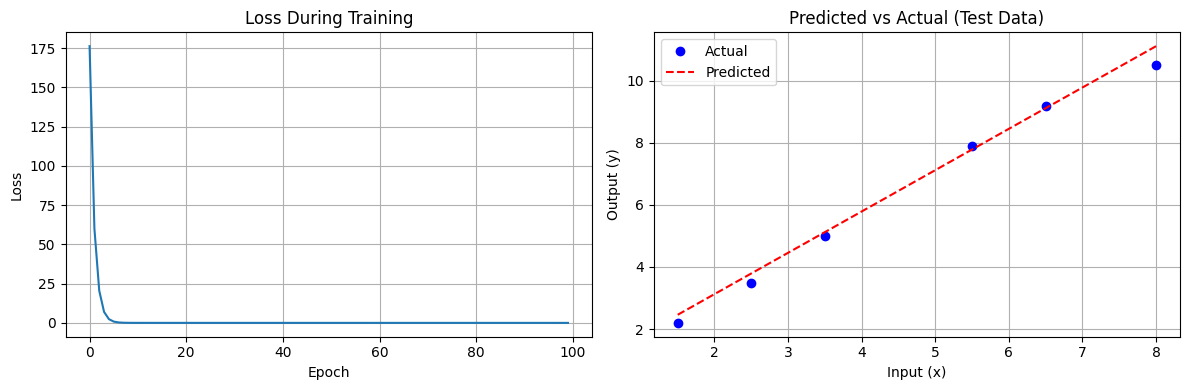

In [ ]:
# Import required libraries
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# -------------------------
# Step 1: Training Data
# -------------------------
# These arrays represent past user data
# x_train = average hours watching movies this week (input)
# y_train = hours spent on the platform next week (target/output)
x_train = np.array([1, 2, 3, 4, 5, 6, 7], dtype=float)
y_train = np.array([1.5, 3.1, 4.2, 6.0, 7.1, 8.5, 9.8], dtype=float)

# -------------------------
# Step 2: Test Data
# -------------------------
# This is new/unseen data that we want to test our model on
x_test = np.array([1.5, 2.5, 3.5, 5.5, 6.5, 8.0], dtype=float)
y_test = np.array([2.2, 3.5, 5.0, 7.9, 9.2, 10.5], dtype=float)  # Actual results for testing

# -------------------------
# Step 3: Build the Model
# -------------------------
# A model with 1 layer and 1 neuron, simple linear relationship
model = keras.Sequential([
    keras.layers.Dense(units=1, input_shape=[1])
])

# -------------------------
# Step 4: Compile the Model
# -------------------------
# optimizer = how the model updates itself during training
# loss = how the model measures error
model.compile(optimizer='sgd', loss='mean_squared_error')

# -------------------------
# Step 5: Train the Model
# -------------------------
# The model will look at the data many times (epochs) to learn the pattern
print("Training the model...")
history = model.fit(x_train, y_train, epochs=100, verbose=0)

# -------------------------
# Step 6: Use Model to Predict Test Data
# -------------------------
# Now we ask the model to make predictions on new data
predictions = model.predict(x_test)

# Show each prediction alongside the actual value
print("\n=== Predictions vs Actual (Test Data) ===")
for i in range(len(x_test)):
    print(f"Input: {x_test[i]} -> Prediction: {predictions[i][0]:.2f}, Actual: {y_test[i]}")

# -------------------------
# Step 7: Plot Training Loss
# -------------------------
# This shows how much the model improved over time
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.title('Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# -------------------------
# Step 8: Plot Predictions vs Actual
# -------------------------
# This compares the model's predictions to the real values
plt.subplot(1, 2, 2)
plt.plot(x_test, y_test, 'bo', label='Actual')        # Blue dots = actual
plt.plot(x_test, predictions, 'r--', label='Predicted')  # Red dashed line = predicted
plt.title('Predicted vs Actual (Test Data)')
plt.xlabel('Input (x)')
plt.ylabel('Output (y)')
plt.legend()
plt.grid(True)

# Show both plots side by side
plt.tight_layout()
plt.show()